In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dynamics import *
from typing import Optional, Tuple

from MonteCarlo_Function import *

In [2]:
""" Probability of Invader-driven survivors- Computed by generating dynamics.
Task: n samples independent λ-sets, integrate to T=100, count survivors, plot P(k)."""

#create invader driven fitness matrix
def make_fit(invader):
    """Build A with off-diagonal A_ij = λ_i and A_ii = 0."""
    n = len(invader)
    fit = np.zeros((n,n))
    for i in range (0, n):
        for j in range (0, n):
            if i != j:
                fit[i,j] = invader[i]
    return fit

In [3]:
def count_survivor_cases(n, N, T):
    counts = np.zeros(n + 1, dtype=int)

    for _ in range(N):
        invader = np.random.rand(n)                 # λ_i ~ U(0,1)

        # your invader-driven A: A_ij = λ_i for i≠j, A_ii = 0
        A = make_fit(invader)

        z0 = np.random.rand(n)
        z0 = z0/sum(z0)
        A, resultat, nc = simu(T = T, fit=A, z0 = z0, V_threshold = 10**(-2))
        zT = resultat.y[:,-1]
        
        k = nc
        counts[k] += 1

    probs = counts / float(N)
    return counts, probs

In [4]:
def plot_survivor_probs(probs: np.ndarray,
                        title: Optional[str] = None,
                        start_k: int = 1) -> None:
    n = len(probs) - 1
    ks = np.arange(start_k, n + 1)
    vals = probs[start_k:]
    plt.figure(figsize=(6, 4))
    plt.bar(ks, vals)
    plt.xticks(ks)
    plt.xlabel("# surviving strains at T")
    plt.ylabel("Probability")
    plt.title(title or f"Invader-driven survivors (n={n})")
    plt.tight_layout()
    plt.show()

 2     95 0.009500
 3   1630 0.163000
 4   4006 0.400600
 5   3122 0.312200
 6    996 0.099600
 7    144 0.014400
 8      6 0.000600
 9      1 0.000100


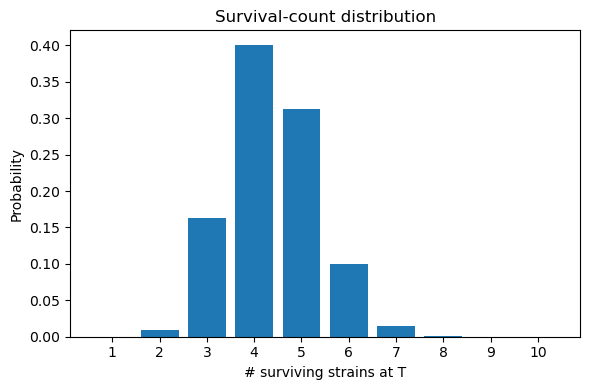

In [8]:
# Case 10-strain dynamics
counts, probs = count_survivor_cases(n=10, N = 10000, T=400.0)
for k in range(1, len(counts)):  # skip k=0
    if counts[k]:
        print(f"{k:2d} {counts[k]:6d} {probs[k]:.6f}")
plot_survivor_probs(probs, title="Survival-count distribution")

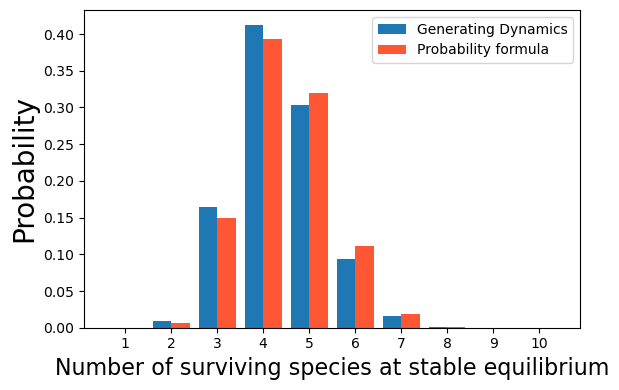

<Figure size 640x480 with 0 Axes>

In [6]:
#Comparison

#Probs computed by generating dynamics
N = 10
n = len(probs) - 1
ks = np.arange(1, n + 1)
tick_labels = ks.astype(str).tolist() 
vals = probs[1:]

#Probs computed by integral formula
mc = probs_all(N)
mc = np.insert(mc, 0, 0)

#Plot for comparison
plt.figure(figsize=(6, 4))
bar_width = 0.4
plt.bar(ks, vals, bar_width, color = '#1f77b4', label = 'Generating Dynamics')
plt.bar(ks+bar_width, mc, bar_width, color = '#FF5733', label = 'Probability formula')

plt.xticks(ticks= ks+bar_width / 2, labels = tick_labels)
plt.xlabel("Number of surviving species at stable equilibrium", fontsize = 16)
plt.ylabel("Probability", fontsize = 20)
#plt.title(title or f"Invader-driven survivors (n={n})")

plt.legend(loc= 'best')
plt.tight_layout()
plt.show()

plt.savefig('10strains_probs.png', dpi=300, bbox_inches='tight')

 3     53 0.005300
 4    624 0.062400
 5   2246 0.224600
 6   3337 0.333700
 7   2427 0.242700
 8   1001 0.100100
 9    253 0.025300
10     53 0.005300
11      6 0.000600


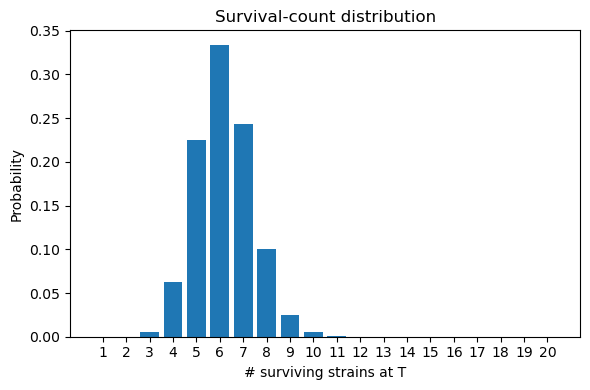

In [5]:
# Case 20-strain dynamics
counts, probs = count_survivor_cases(n = 20, N = 10000, T = 200.0)
for k in range(1, len(counts)):  # skip k=0
    if counts[k]:
        print(f"{k:2d} {counts[k]:6d} {probs[k]:.6f}")
plot_survivor_probs(probs, title="Survival-count distribution")

 3     44 0.004400
 4    684 0.068400
 5   2321 0.232100
 6   3311 0.331100
 7   2368 0.236800
 8    949 0.094900
 9    278 0.027800
10     41 0.004100
11      4 0.000400


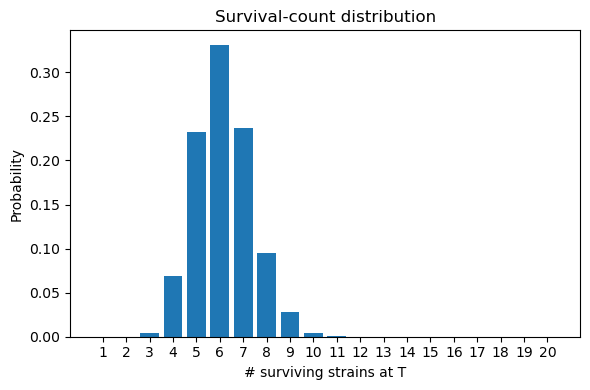

In [7]:
# Case 20-strain dynamics
counts, probs = count_survivor_cases(n = 20, N = 10000, T = 200.0)
for k in range(1, len(counts)):  # skip k=0
    if counts[k]:
        print(f"{k:2d} {counts[k]:6d} {probs[k]:.6f}")
plot_survivor_probs(probs, title="Survival-count distribution")

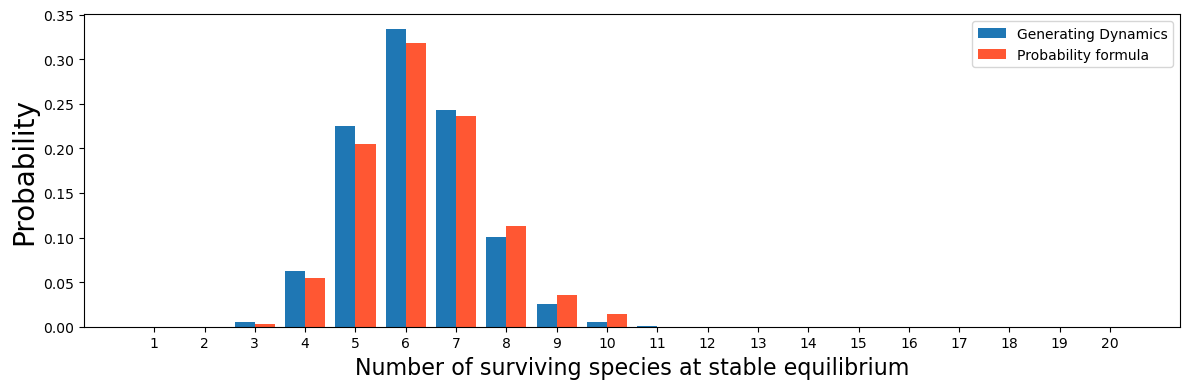

<Figure size 640x480 with 0 Axes>

In [6]:
#Comparison

#Probs computed by generating dynamics
N = 20
n = len(probs) - 1
ks = np.arange(1, n + 1)
tick_labels = ks.astype(str).tolist() 
vals = probs[1:]

#Probs computed by integral formula
mc = probs_all(N)
mc = np.insert(mc, 0, 0)

#Plot for comparison
plt.figure(figsize=(12, 4))
bar_width = 0.4
plt.bar(ks, vals, bar_width, color = '#1f77b4', label = 'Generating Dynamics')
plt.bar(ks+bar_width, mc, bar_width, color = '#FF5733', label = 'Probability formula')

plt.xticks(ticks= ks+bar_width / 2, labels = tick_labels)
plt.xlabel("Number of surviving species at stable equilibrium", fontsize = 16)
plt.ylabel("Probability", fontsize = 20)
#plt.title(title or f"Invader-driven survivors (n={n})")

plt.legend(loc= 'best')
plt.tight_layout()
plt.show()

plt.savefig('20strains_probs.png', dpi=300, bbox_inches='tight')

 2   1929 0.192900
 3   5527 0.552700
 4   2328 0.232800
 5    216 0.021600


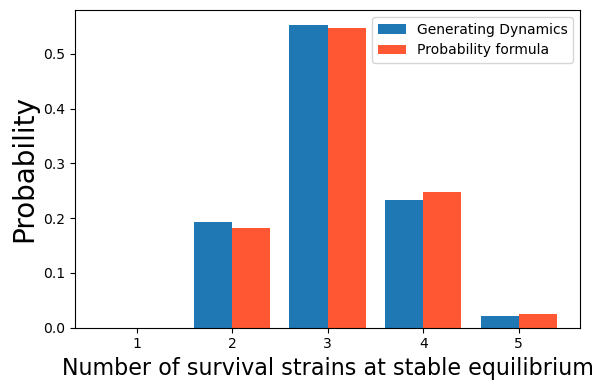

<Figure size 640x480 with 0 Axes>

In [20]:
counts, probs = count_survivor_cases(n=5, N=10000, T=400.0)
for k in range(1, len(counts)):  # skip k=0
    if counts[k]:
        print(f"{k:2d} {counts[k]:6d} {probs[k]:.6f}")

#Probs computed by generating dynamics
n = len(probs) - 1
ks = np.arange(1, n + 1)
tick_labels = ks.astype(str).tolist() 
vals = probs[1:]

#Probs computed by integral formula
mc = probs_all(N=5)
mc = np.insert(mc, 0, 0)

#Plot for comparison
plt.figure(figsize=(6, 4))
bar_width = 0.4
plt.bar(ks, vals, bar_width, color = '#1f77b4', label = 'Generating Dynamics')
plt.bar(ks+bar_width, mc, bar_width, color = '#FF5733', label = 'Probability formula')

plt.xticks(ticks= ks+bar_width / 2, labels = tick_labels)
plt.xlabel("Number of survival strains at stable equilibrium", fontsize = 16)
plt.ylabel("Probability", fontsize = 20)
#plt.title(title or f"Invader-driven survivors (n={n})")

plt.legend(loc= 'best')
plt.tight_layout()
plt.show()

plt.savefig('5strains_probs.png', dpi=300, bbox_inches='tight')